# `preion.forecast` tutorial

End-to-end walk-through of the forecast pipeline: build a config, generate
mock kSZ/tau/BB data with `make_datapoints`, run a (short, for this notebook)
`emcee` MCMC with `run_mcmc`, then read back and diagnose the
chain the way `preion-read-mcmc` does.

In [1]:
import shutil
import tempfile
from pathlib import Path
import numpy as np

from preion.forecast import config, datapoints, mcmc, read_mcmc

%matplotlib inline

could not load wigners.so fortran shared object
try f2py -c -m wigners wigners.f90 from the command line in wigners directory ?


## 1. Load a config

`config.load_config` reads a YAML file and fills in defaults matching the
values that used to be hardcoded in `run_mcmc_cv_limited_new.py`. We start
from the packaged example config and shrink it to a tiny, fast run in a
scratch directory.

In [2]:
run_dir = Path(tempfile.mkdtemp(prefix='preion_forecast_tutorial_'))

In [3]:
cfg = config.load_config('../configs/config_tutorial_mcmc.yaml')
cfg['output_dir'] = str(run_dir)
print(cfg)

{'label': 'mcmc_tutorial', 'data': 'all', 'theta_true': [7.0, 1.5, 3.7, 0.1], 'log_kappa': True, 'niterations': 10, 'nwalkers': 4, 'fsky': 1.0, 'use_ksz_emulator': False, 'overwrite': True, 'plot': False, 'progress': True, 'telescopes': None, 'output_dir': '/tmp/preion_forecast_tutorial_nwedfdao', 'ells': {'tau': {'start': 100, 'stop': 5000, 'step': 100}, 'ksz': {'start': 1000, 'stop': 8000, 'step': 500}, 'bb': {'start': 10, 'stop': 1000, 'num': 50}}}


## 2. Generate mock data directly

`mcmc.get_or_make_datapoints` will do this automatically (reading cached
datapoints back from disk if they already exist), but it's useful to see
`make_datapoints` on its own. If `telescopes=None` then the forecast is
cosmic-variance limited.

In [ ]:
# ells_tau, ells_ksz, ells_bb
# note that the ells are the edges of the multipole bins to consider in the forecast
ells = np.array([[100, 200], [1000, 2000], [100, 200]])
tau_ps, ksz_ps, bb_ps, cov_tau, cov_ksz, cov_bb = datapoints.make_datapoints(
    cfg['theta_true'], telescopes=cfg['telescopes'], ells=ells,
    use_ksz_emulator=cfg['use_ksz_emulator'],
)  # takes a couple minutes to run
print('tau_ps:', tau_ps)

## 3. Run the MCMC

Rather than regenerating mock data (which reruns CAMB) every time, we load a
pre-computed cosmic-variance-limited dataset shipped with the package via
`datapoints.load_packaged_datapoints()`, then `mcmc.run_mcmc(datapoints_dict, cfg)`
runs `emcee` against it and writes the chain to `{output_dir}/backends/`.

Status/timing/diagnostic messages are written to a logfile at
`{output_dir}/{label}.log` instead of the console — only the `emcee`/`tqdm`
progress bar (since `progress: true` in the config) shows up here.

In [4]:
datapoints_dict = datapoints.load_packaged_datapoints()

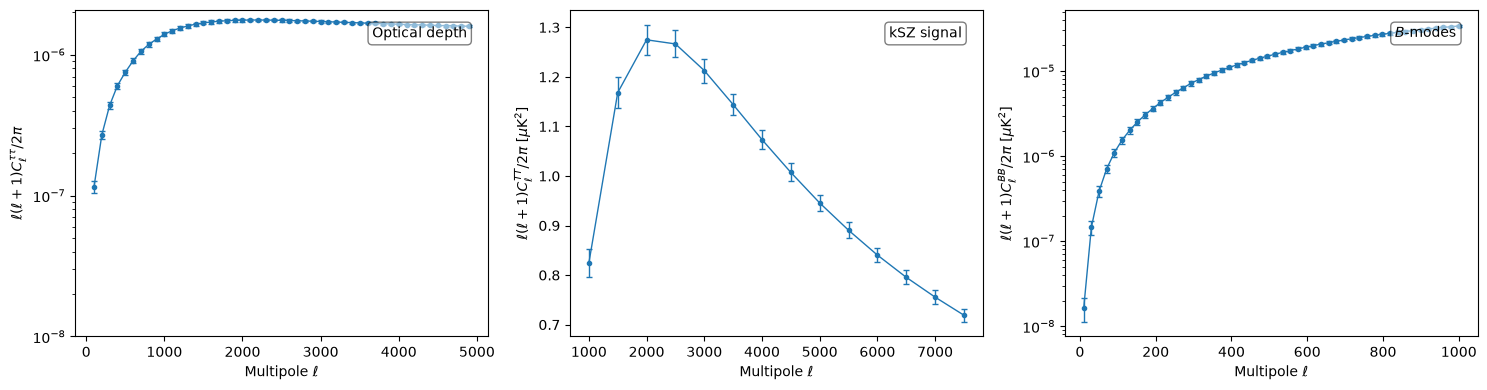

In [5]:
fig, axes = mcmc.plot_obs(cfg, datapoints=datapoints_dict)

In [ ]:
sampler = mcmc.run_mcmc(datapoints_dict, cfg)

In [ ]:
log_path = run_dir / f"{cfg['label']}.log"
print(log_path.read_text())

## 4. Read back and diagnose the chain

This mirrors what `preion-read-mcmc configs/cv_limited_new.yaml` does on the
command line: load the chain, compute convergence diagnostics, flatten the
post-burn-in samples, and plot a corner/trace/posterior-predictive figure.

In [ ]:
ells = []
data, cov = {}, {}
for dat in ['tau', 'ksz', 'bb']:
    ells.append(datapoints_dict[f"ells_{dat}"])
    data[dat] = datapoints_dict[dat]
    cov[dat] = datapoints_dict[f"cov_{dat}"]

In [ ]:
sampler = read_mcmc.load_chain(cfg)
diagnostics = read_mcmc.convergence_diagnostics(sampler)
print(f"Auto-correlation time: {diagnostics['endtau']:.2f}. Converged: {diagnostics['converged']}.")
print(f"burnin = {diagnostics['burnin']} steps")

In [ ]:
flatsamples, logps = read_mcmc.get_flat_samples(sampler, diagnostics['burnin'])
truths = read_mcmc._theta_true(cfg)
labels = read_mcmc._theta_labels(cfg)
summary = read_mcmc.summarize(flatsamples, truths, read_mcmc.PARAM_NAMES)

In [ ]:
fig_corner = read_mcmc.plot_corner(flatsamples, truths, labels)

In [ ]:
fig_trace = read_mcmc.plot_trace(sampler, read_mcmc.PARAM_NAMES, diagnostics['burnin'])

In [ ]:
fig_pp = read_mcmc.plot_posterior_predictive(sampler, ells, data, cov, diagnostics['burnin'])

## 5. Clean up the scratch run directory

In [ ]:
shutil.rmtree(run_dir, ignore_errors=True)